In [ ]:
# C - Visualizations

#This notebook  creates polished visualizations for the Formula 1 tyre strategy ML project.

## Goals
#Create paper-quality figures
#Compare compounds, drivers, teams, and tyre behaviour
#Visualize degradation trends and feature relationships

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)

In [3]:
DATA_PATH = Path("../data/processed/master_dataset.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (11880, 14)


,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds,FuelLoadApprox,StintProgress,CompoundEncoded,FreshTyre,TyreAgeSquared
0,VER,Red Bull Racing,1.0,SOFT,4.0,1.0,2.0,1,83.186,0.984848,0.100,0,0,16.0
1,VER,Red Bull Racing,2.0,SOFT,5.0,1.0,2.0,1,79.871,0.969697,0.125,0,0,25.0
2,VER,Red Bull Racing,3.0,SOFT,6.0,1.0,1.0,1,79.364,0.954545,0.150,0,0,36.0
3,VER,Red Bull Racing,4.0,SOFT,7.0,1.0,1.0,1,80.766,0.939394,0.175,0,0,49.0
4,VER,Red Bull Racing,5.0,SOFT,8.0,1.0,1.0,1,80.827,0.924242,0.200,0,0,64.0


In [5]:
figures_path = Path("../outputs/figures")
figures_path.mkdir(parents=True, exist_ok=True)

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(num_cols)

['LapNumber', 'TyreLife', 'Stint', 'Position', 'TrackStatus', 'LapTimeSeconds', 'FuelLoadApprox', 'StintProgress', 'CompoundEncoded', 'FreshTyre', 'TyreAgeSquared']


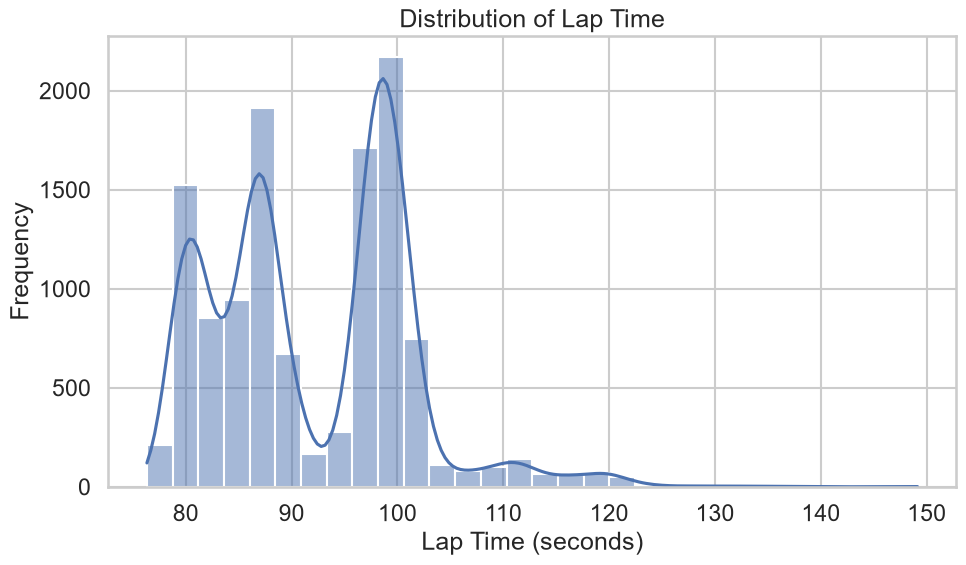

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df["LapTimeSeconds"], bins=30, kde=True)
plt.title("Distribution of Lap Time")
plt.xlabel("Lap Time (seconds)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(figures_path / "viz_lap_time_distribution.png", dpi=300)
plt.show()

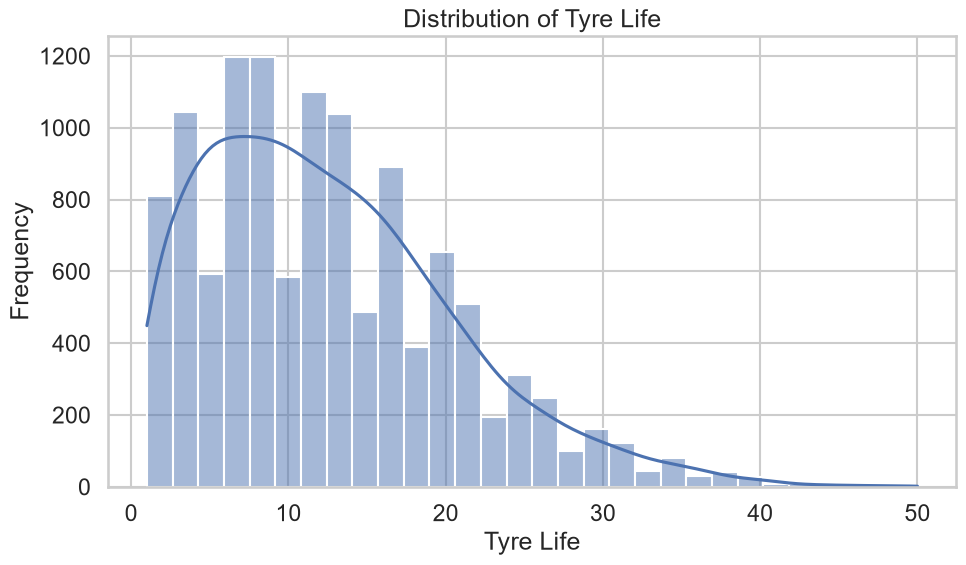

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(df["TyreLife"], bins=30, kde=True)
plt.title("Distribution of Tyre Life")
plt.xlabel("Tyre Life")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(figures_path / "viz_tyre_life_distribution.png", dpi=300)
plt.show()

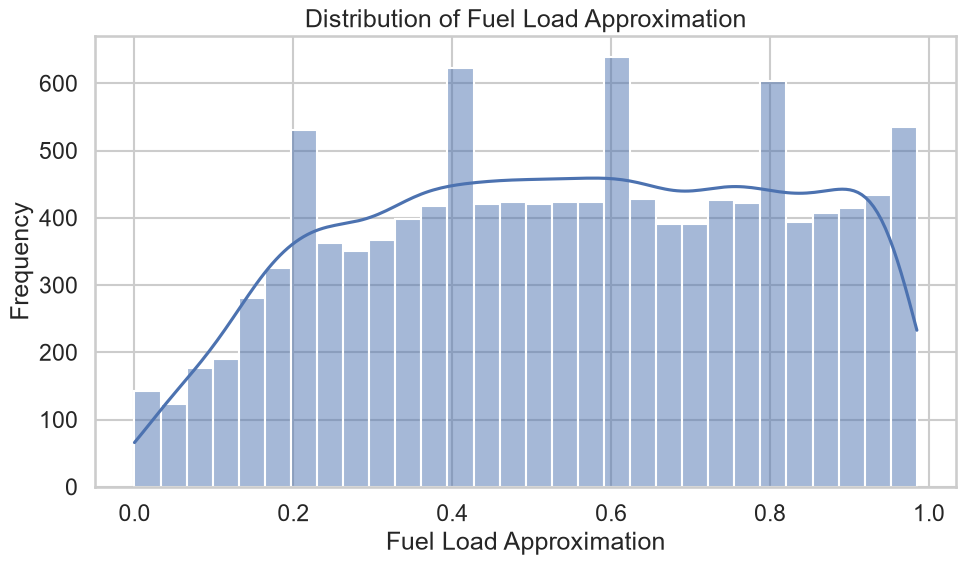

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df["FuelLoadApprox"], bins=30, kde=True)
plt.title("Distribution of Fuel Load Approximation")
plt.xlabel("Fuel Load Approximation")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(figures_path / "viz_fuel_load_distribution.png", dpi=300)
plt.show()

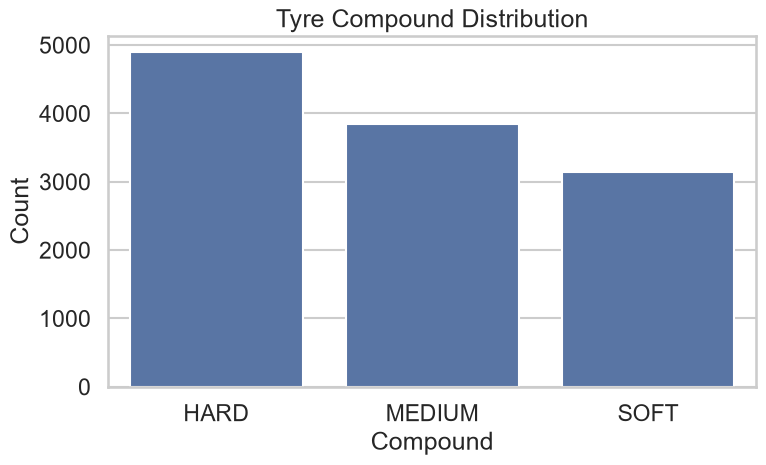

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Compound", order=df["Compound"].value_counts().index)
plt.title("Tyre Compound Distribution")
plt.xlabel("Compound")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(figures_path / "viz_compound_distribution.png", dpi=300)
plt.show()

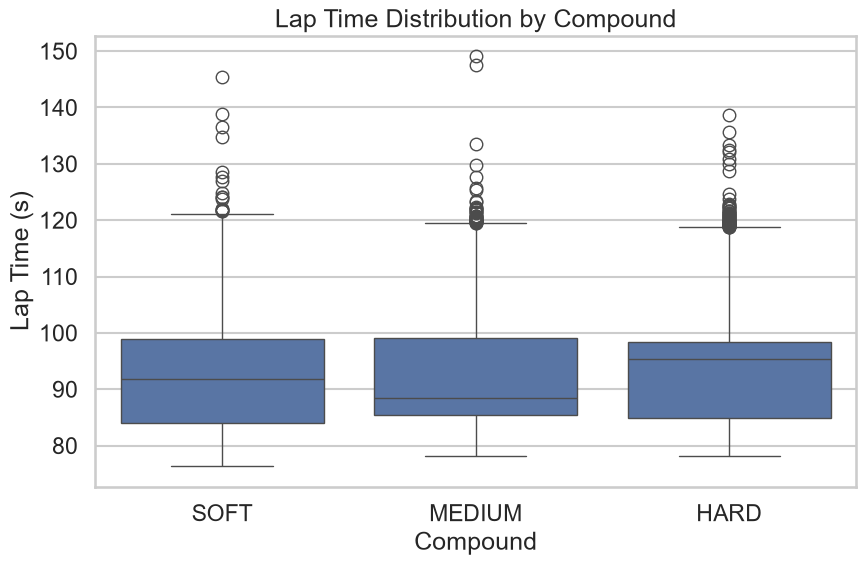

In [11]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="Compound", y="LapTimeSeconds")
plt.title("Lap Time Distribution by Compound")
plt.xlabel("Compound")
plt.ylabel("Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_laptime_by_compound_box.png", dpi=300)
plt.show()

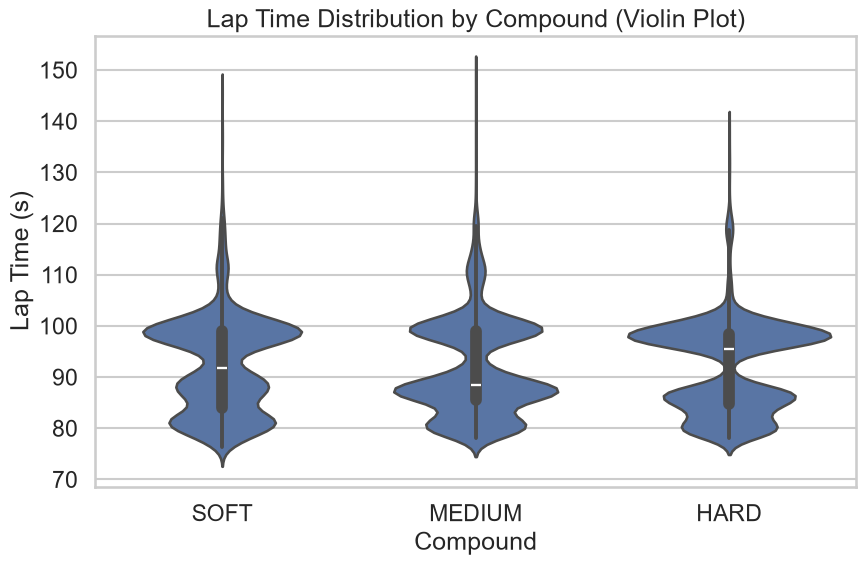

In [12]:
plt.figure(figsize=(9,6))
sns.violinplot(data=df, x="Compound", y="LapTimeSeconds")
plt.title("Lap Time Distribution by Compound (Violin Plot)")
plt.xlabel("Compound")
plt.ylabel("Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_laptime_by_compound_violin.png", dpi=300)
plt.show()

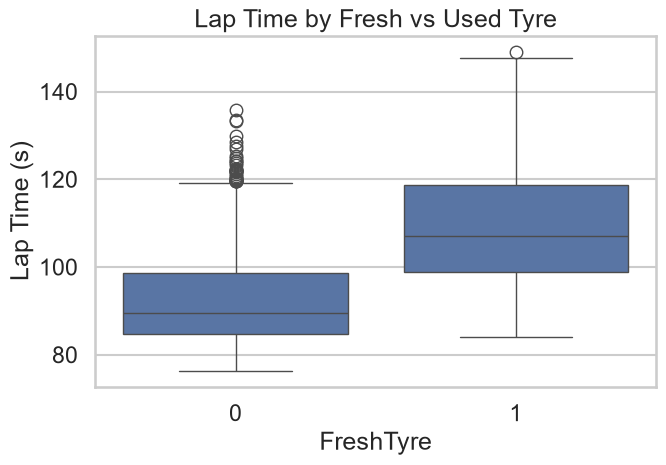

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="FreshTyre", y="LapTimeSeconds")
plt.title("Lap Time by Fresh vs Used Tyre")
plt.xlabel("FreshTyre")
plt.ylabel("Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_laptime_fresh_tyre_box.png", dpi=300)
plt.show()

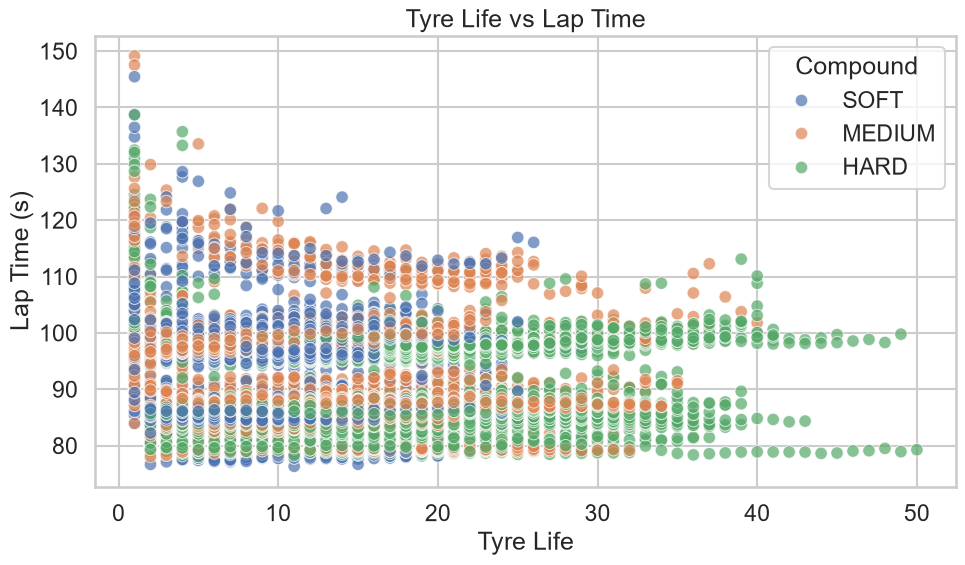

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="TyreLife", y="LapTimeSeconds", hue="Compound", alpha=0.7)
plt.title("Tyre Life vs Lap Time")
plt.xlabel("Tyre Life")
plt.ylabel("Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_tyrelife_vs_laptime_scatter.png", dpi=300)
plt.show()

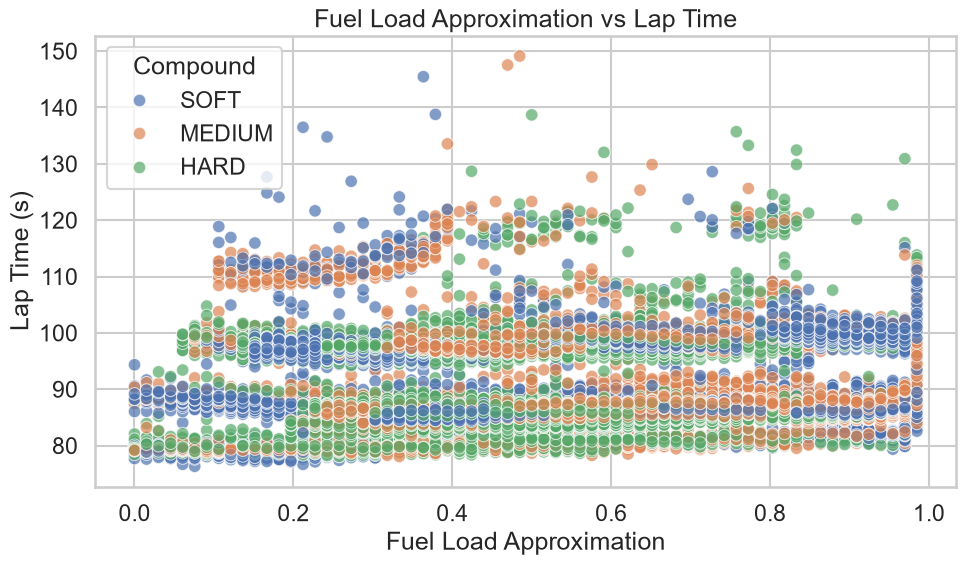

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="FuelLoadApprox", y="LapTimeSeconds", hue="Compound", alpha=0.7)
plt.title("Fuel Load Approximation vs Lap Time")
plt.xlabel("Fuel Load Approximation")
plt.ylabel("Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_fuel_vs_laptime_scatter.png", dpi=300)
plt.show()

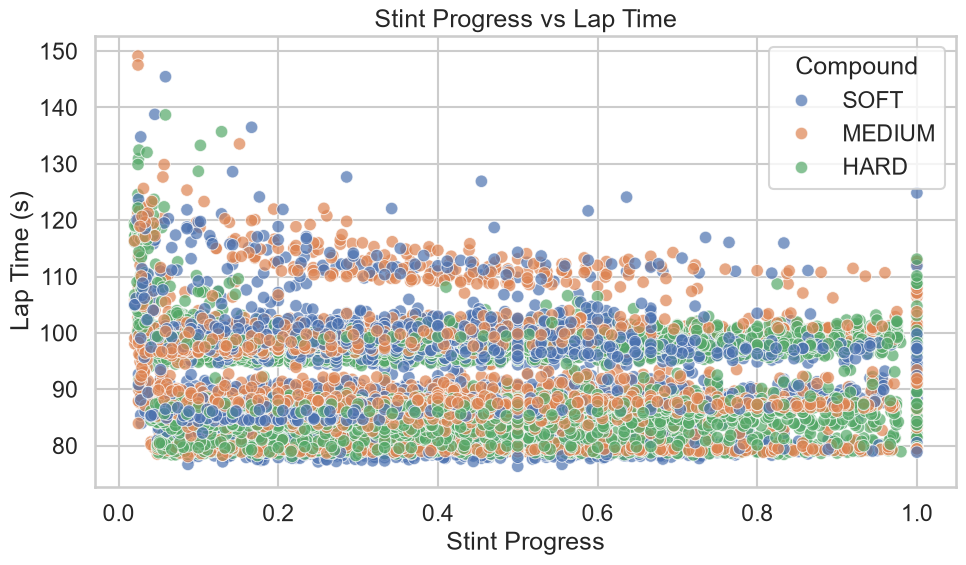

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="StintProgress", y="LapTimeSeconds", hue="Compound", alpha=0.7)
plt.title("Stint Progress vs Lap Time")
plt.xlabel("Stint Progress")
plt.ylabel("Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_stintprogress_vs_laptime.png", dpi=300)
plt.show()

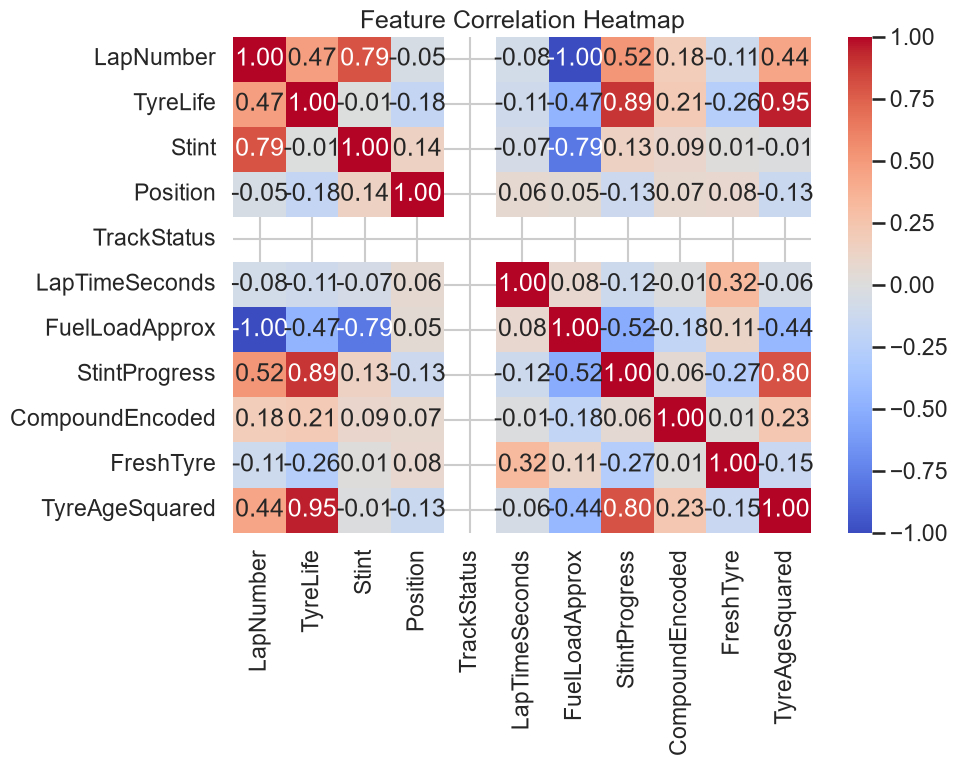

In [17]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(figures_path / "viz_correlation_heatmap.png", dpi=300)
plt.show()


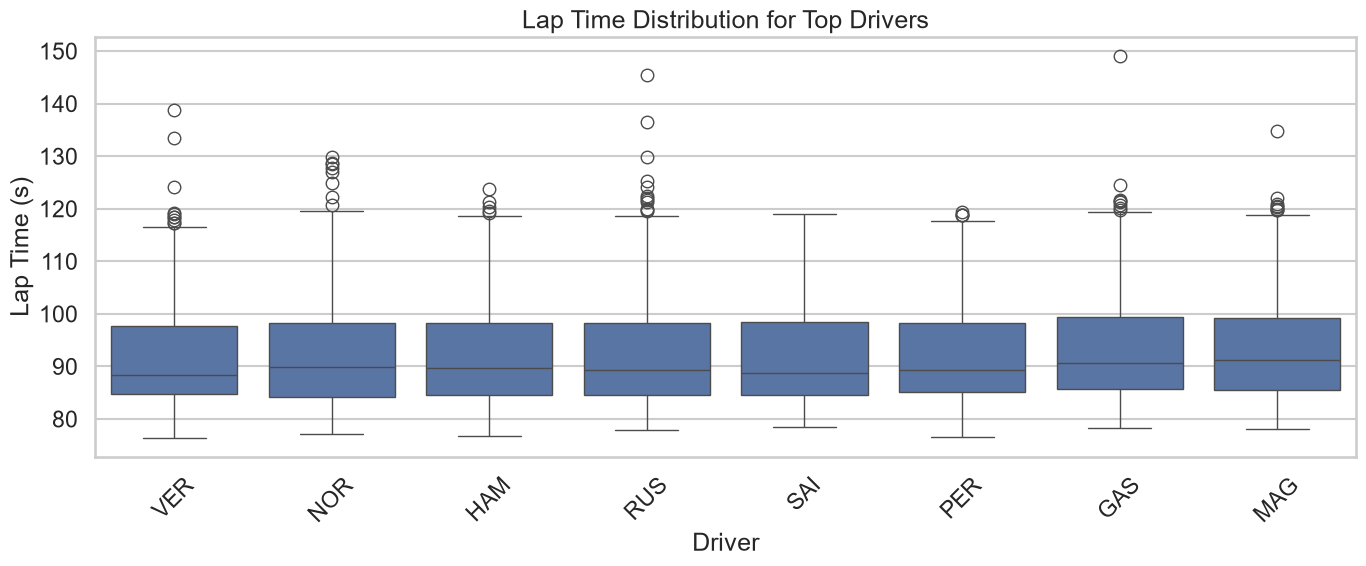

In [18]:
top_drivers = df["Driver"].value_counts().head(8).index
df_top_drivers = df[df["Driver"].isin(top_drivers)]

plt.figure(figsize=(14,6))
sns.boxplot(data=df_top_drivers, x="Driver", y="LapTimeSeconds")
plt.title("Lap Time Distribution for Top Drivers")
plt.xlabel("Driver")
plt.ylabel("Lap Time (s)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_path / "viz_top_drivers_boxplot.png", dpi=300)
plt.show()

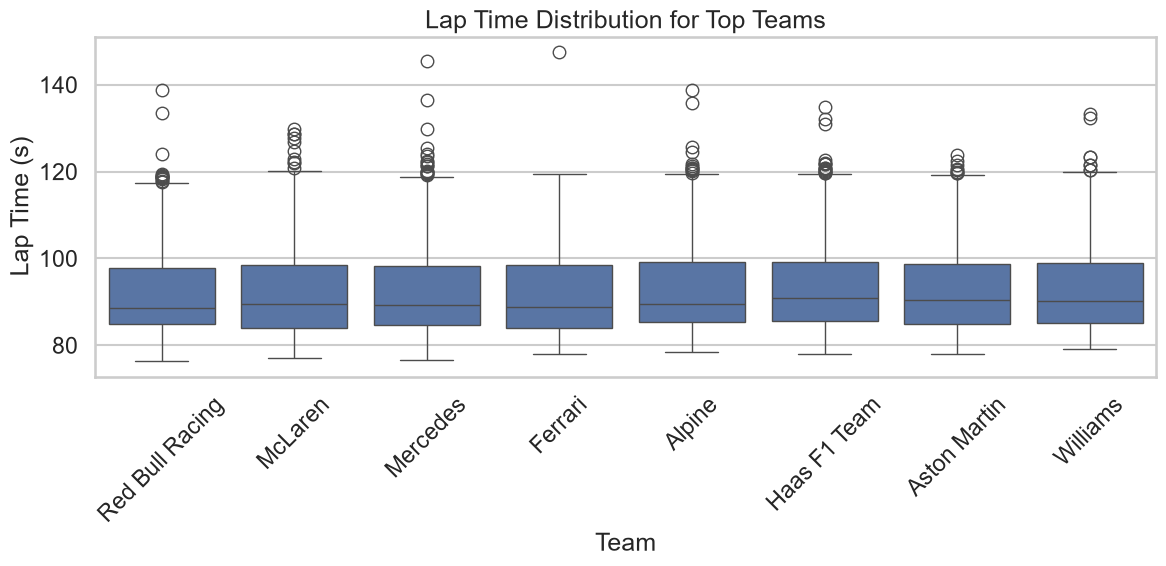

In [19]:
top_teams = df["Team"].value_counts().head(8).index
df_top_teams = df[df["Team"].isin(top_teams)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_teams, x="Team", y="LapTimeSeconds")
plt.title("Lap Time Distribution for Top Teams")
plt.xlabel("Team")
plt.ylabel("Lap Time (s)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_path / "viz_top_teams_boxplot.png", dpi=300)
plt.show()

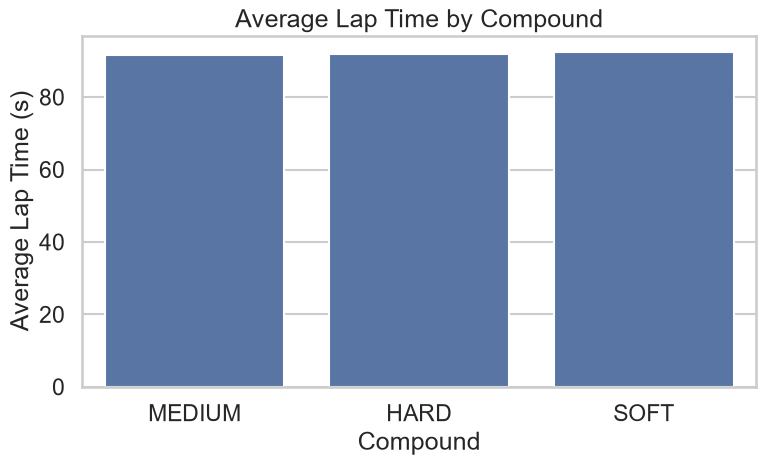

In [20]:
compound_mean = df.groupby("Compound")["LapTimeSeconds"].mean().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=compound_mean.index, y=compound_mean.values)
plt.title("Average Lap Time by Compound")
plt.xlabel("Compound")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_avg_laptime_compound.png", dpi=300)
plt.show()

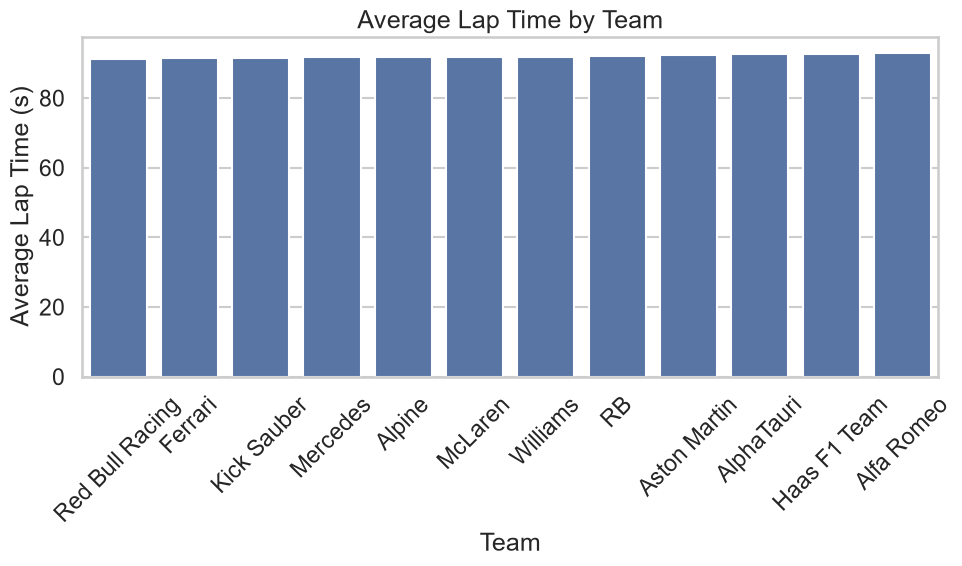

In [21]:
team_mean = df.groupby("Team")["LapTimeSeconds"].mean().sort_values()

plt.figure(figsize=(10,6))
sns.barplot(x=team_mean.index, y=team_mean.values)
plt.title("Average Lap Time by Team")
plt.xlabel("Team")
plt.ylabel("Average Lap Time (s)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_path / "viz_avg_laptime_team.png", dpi=300)
plt.show()

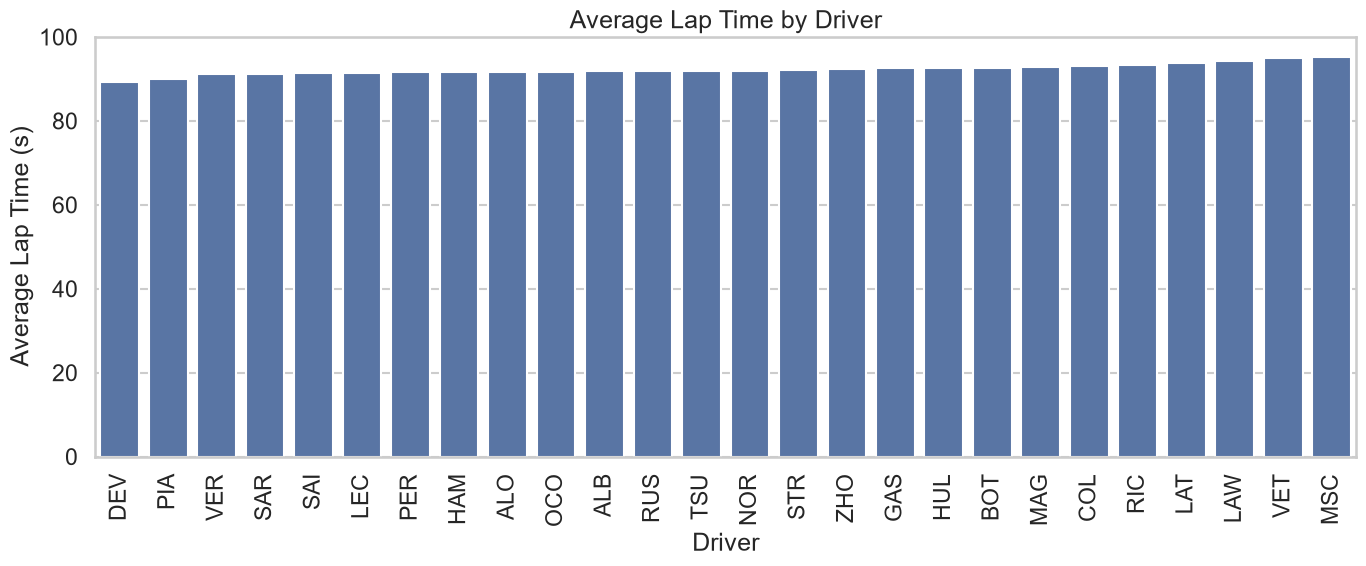

In [22]:
driver_mean = df.groupby("Driver")["LapTimeSeconds"].mean().sort_values()

plt.figure(figsize=(14,6))
sns.barplot(x=driver_mean.index, y=driver_mean.values)
plt.title("Average Lap Time by Driver")
plt.xlabel("Driver")
plt.ylabel("Average Lap Time (s)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(figures_path / "viz_avg_laptime_driver.png", dpi=300)
plt.show()

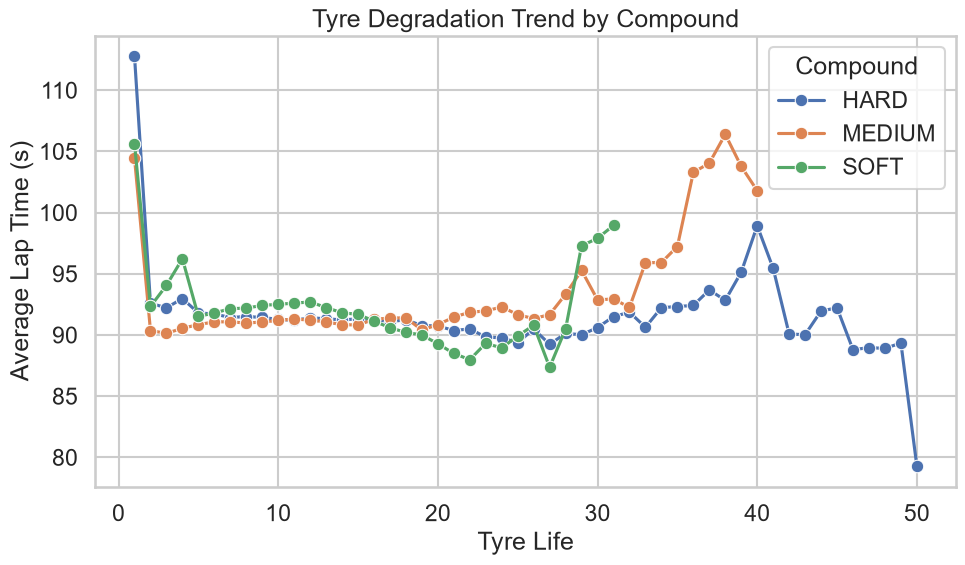

In [23]:
degradation_compound = (
    df.groupby(["Compound", "TyreLife"])["LapTimeSeconds"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=degradation_compound,
    x="TyreLife",
    y="LapTimeSeconds",
    hue="Compound",
    marker="o"
)
plt.title("Tyre Degradation Trend by Compound")
plt.xlabel("Tyre Life")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_degradation_compound.png", dpi=300)
plt.show()

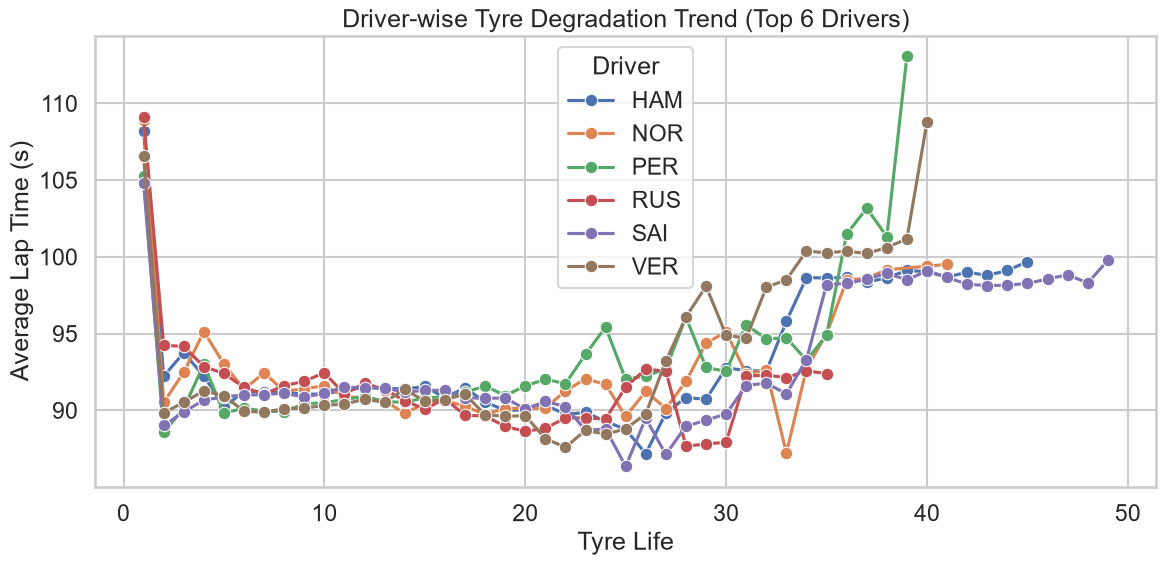

In [24]:
driver_degradation = (
    df.groupby(["Driver", "TyreLife"])["LapTimeSeconds"]
    .mean()
    .reset_index()
)

top_driver_subset = df["Driver"].value_counts().head(6).index
driver_degradation_subset = driver_degradation[
    driver_degradation["Driver"].isin(top_driver_subset)
]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=driver_degradation_subset,
    x="TyreLife",
    y="LapTimeSeconds",
    hue="Driver",
    marker="o"
)
plt.title("Driver-wise Tyre Degradation Trend (Top 6 Drivers)")
plt.xlabel("Tyre Life")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_driver_degradation_top6.png", dpi=300)
plt.show()

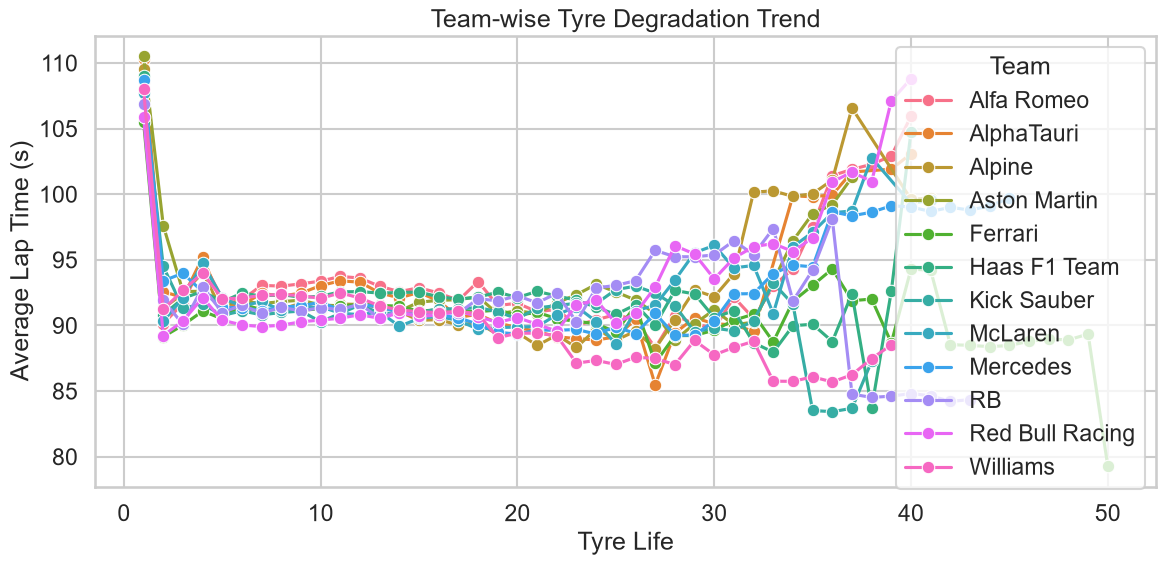

In [25]:
team_degradation = (
    df.groupby(["Team", "TyreLife"])["LapTimeSeconds"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=team_degradation,
    x="TyreLife",
    y="LapTimeSeconds",
    hue="Team",
    marker="o"
)
plt.title("Team-wise Tyre Degradation Trend")
plt.xlabel("Tyre Life")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_team_degradation.png", dpi=300)
plt.show()

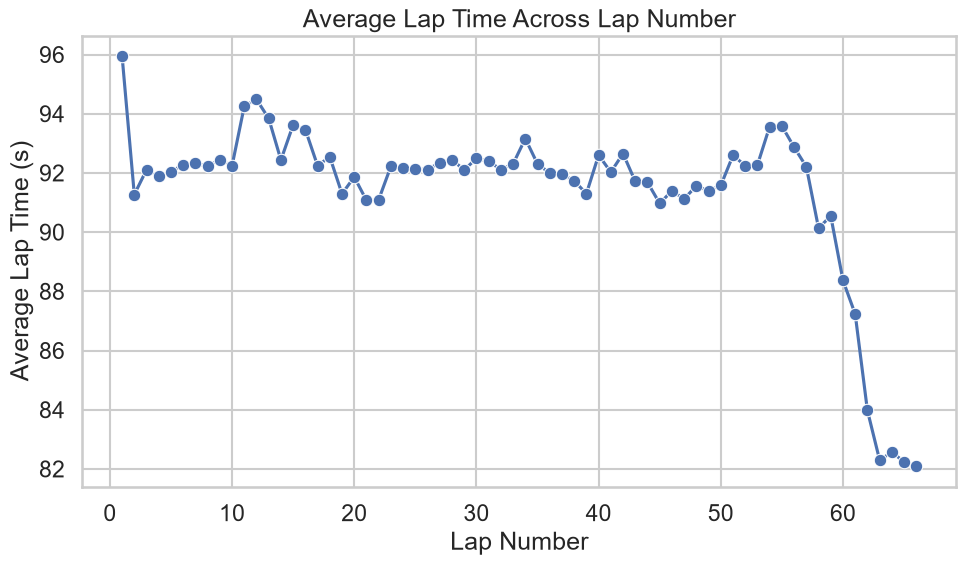

In [26]:
lap_progress = (
    df.groupby("LapNumber")["LapTimeSeconds"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.lineplot(data=lap_progress, x="LapNumber", y="LapTimeSeconds", marker="o")
plt.title("Average Lap Time Across Lap Number")
plt.xlabel("Lap Number")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_lapnumber_vs_laptime.png", dpi=300)
plt.show()

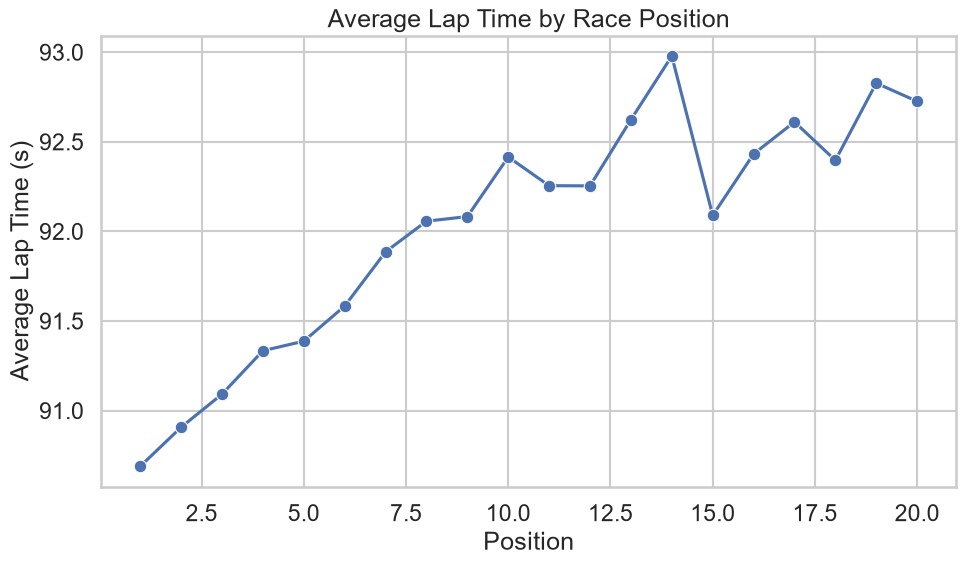

In [27]:
position_perf = (
    df.groupby("Position")["LapTimeSeconds"]
    .mean()
    .reset_index()
    .sort_values("Position")
)

plt.figure(figsize=(10,6))
sns.lineplot(data=position_perf, x="Position", y="LapTimeSeconds", marker="o")
plt.title("Average Lap Time by Race Position")
plt.xlabel("Position")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_position_vs_laptime.png", dpi=300)
plt.show()


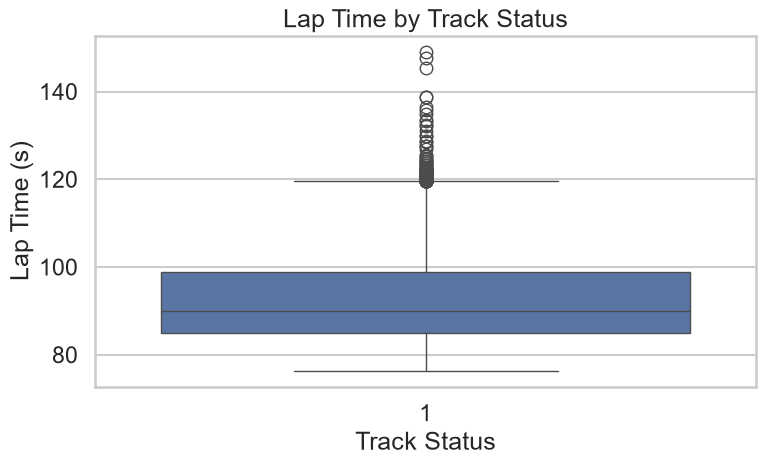

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="TrackStatus", y="LapTimeSeconds")
plt.title("Lap Time by Track Status")
plt.xlabel("Track Status")
plt.ylabel("Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "viz_trackstatus_boxplot.png", dpi=300)
plt.show()

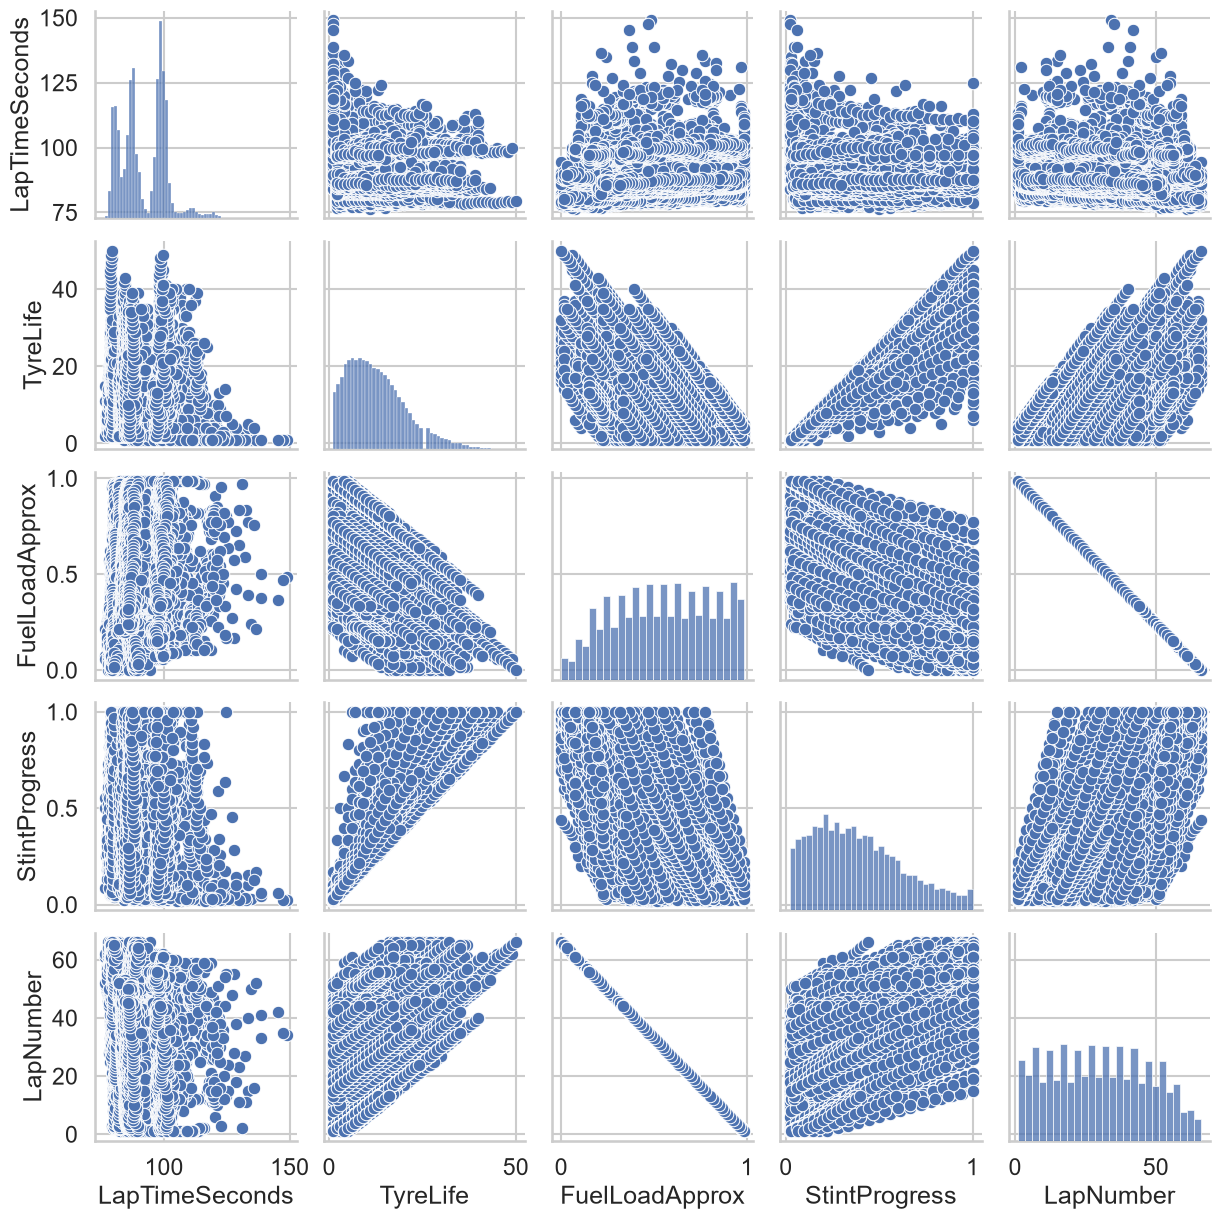

In [29]:
pairplot_cols = ["LapTimeSeconds", "TyreLife", "FuelLoadApprox", "StintProgress", "LapNumber"]
sns.pairplot(df[pairplot_cols].dropna())
plt.savefig(figures_path / "viz_pairplot_key_features.png", dpi=300)
plt.show()

In [30]:
print("Visualization notebook completed.")
print("Saved figures are available in:", figures_path)

Visualization notebook completed.
Saved figures are available in: ..\outputs\figures
